# Exploratory Data Analysis and Simple Linear Regression
This notebook demonstrates exploratory data analysis (EDA) and simple linear regression using a dataset on automobiles.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

## Loading and Viewing the Dataset
Here, we load the dataset and display the first few rows to understand its structure.

In [56]:
df = pd.read_excel('autoMPG_data.xlsx')
df.head()

,GallonsPer100Miles,GallonsPer100MilesTo1981,MPG,Cylinders,Displacement100ci,Horsepower100,Weight1000lb,Seconds0to60,Year,Year70To81,Origin,Origin.Eq.1,Origin.Eq.2,Origin.Eq.3,Name
387,3.703704,NaN,27.0,4,1.40,0.86,2.790,15.6,82,0,1,1,0,0,ford mustang gl
388,2.272727,NaN,44.0,4,0.97,0.52,2.130,24.6,82,0,2,0,1,0,vw pickup
389,3.125000,NaN,32.0,4,1.35,0.84,2.295,11.6,82,0,1,1,0,0,dodge rampage
390,3.571429,NaN,28.0,4,1.20,0.79,2.625,18.6,82,0,1,1,0,0,ford ranger
391,3.225806,NaN,31.0,4,1.19,0.82,2.720,19.4,82,0,1,1,0,0,chevy s-10


## Data cleaning
We clean the data by remove the model name because it doesn't help in determining fuel consumption. Next we remove GallonsPer100MilesTo1981 and Year 70 To 81 columns because they are redundant thanks to the GallonsPer100Miles and Year columns respectively. We remove Origin.Eq.1/2/3 as well as they are redundant because of Origin column. 

In [57]:
if "Name" in df.columns: df.drop(columns=["Name"], inplace=True)
if "GallonsPer100MilesTo1981" in df.columns: df.drop(columns=["GallonsPer100MilesTo1981"], inplace=True)
if "Year70To81" in df.columns: df.drop(columns=["Year70To81"], inplace=True)
if "Origin.Eq.1" in df.columns: df.drop(columns=["Origin.Eq.1"], inplace=True)
if "Origin.Eq.2" in df.columns: df.drop(columns=["Origin.Eq.2"], inplace=True)
if "Origin.Eq.3" in df.columns: df.drop(columns=["Origin.Eq.3"], inplace=True)

## Exploring Columns of Interest
We look at the minimum, maximum and average values of the columns to understand its range.

In [58]:
for col in df.columns:
    print(f"{col}: {min(df[col])} - {max(df[col])} (Average: {df[col].mean()})\n")
    
# Maybe remove the new line at the end, not sure which one looks better

GallonsPer100Miles: 2.1459227467811157 - 11.11111111111111 (Average: 4.782242789602456)

MPG: 9.0 - 46.6 (Average: 23.445918367346938)

Cylinders: 3 - 8 (Average: 5.471938775510204)

Displacement100ci: 0.68 - 4.55 (Average: 1.9441198979591838)

Horsepower100: 0.46 - 2.3 (Average: 1.0446938775510206)

Weight1000lb: 1.613 - 5.14 (Average: 2.977584183673469)

Seconds0to60: 8.0 - 24.8 (Average: 15.541326530612244)

Year: 70 - 82 (Average: 75.9795918367347)

Origin: 1 - 3 (Average: 1.5765306122448979)



## Visualizing Distributions
We create histograms to visualize the distributions of `Weight1000lb` and `MPG` columns.

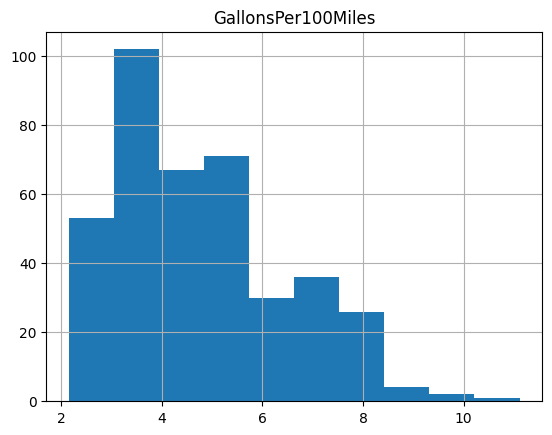

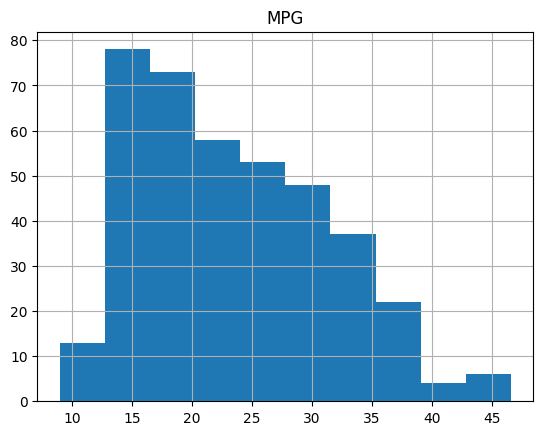

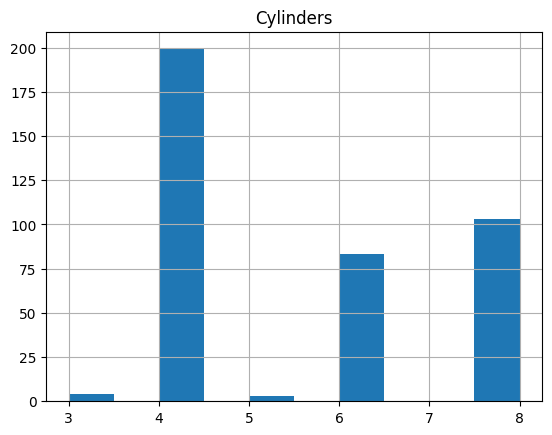

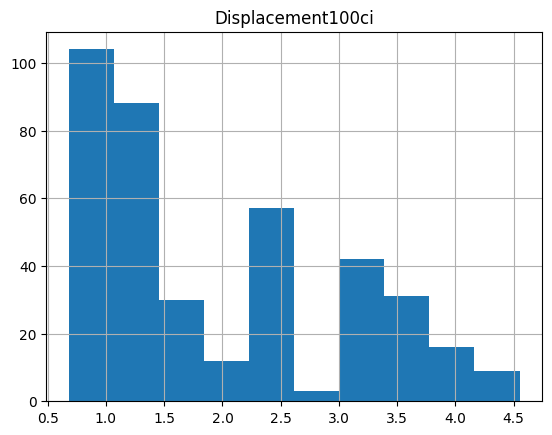

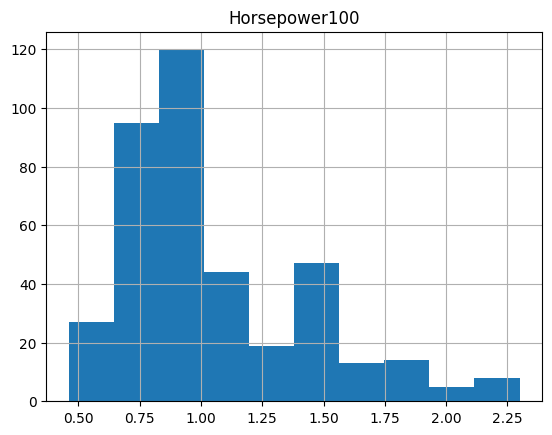

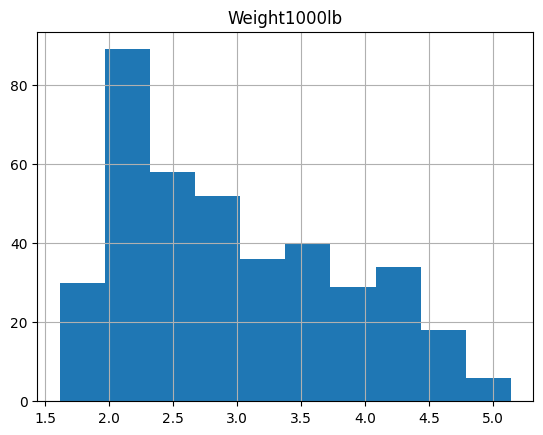

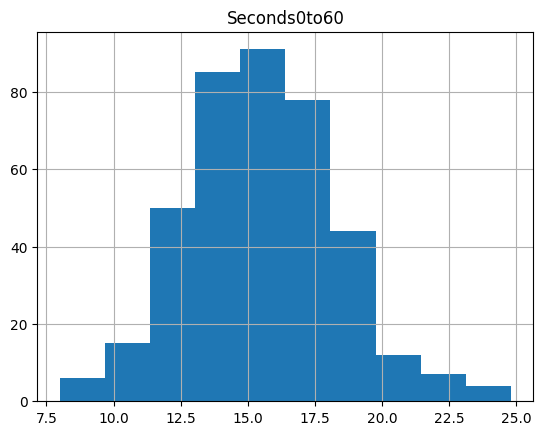

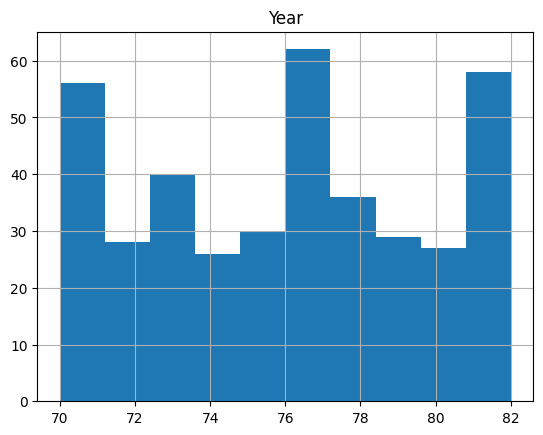

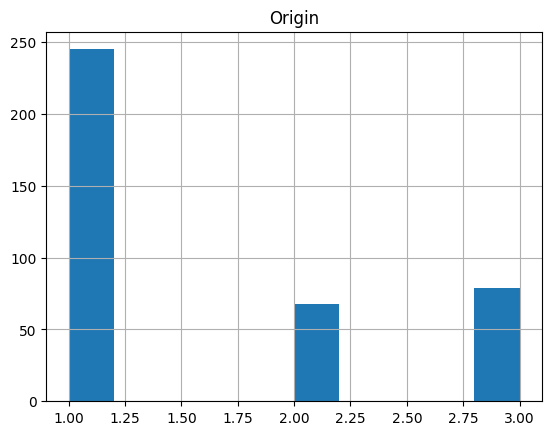

In [59]:
for col in df.columns:
    df[col].hist()
    plt.title(col)
    plt.show()

## Pairwise Relationships
We use `sns.pairplot` to explore pairwise relationships among all numerical columns.

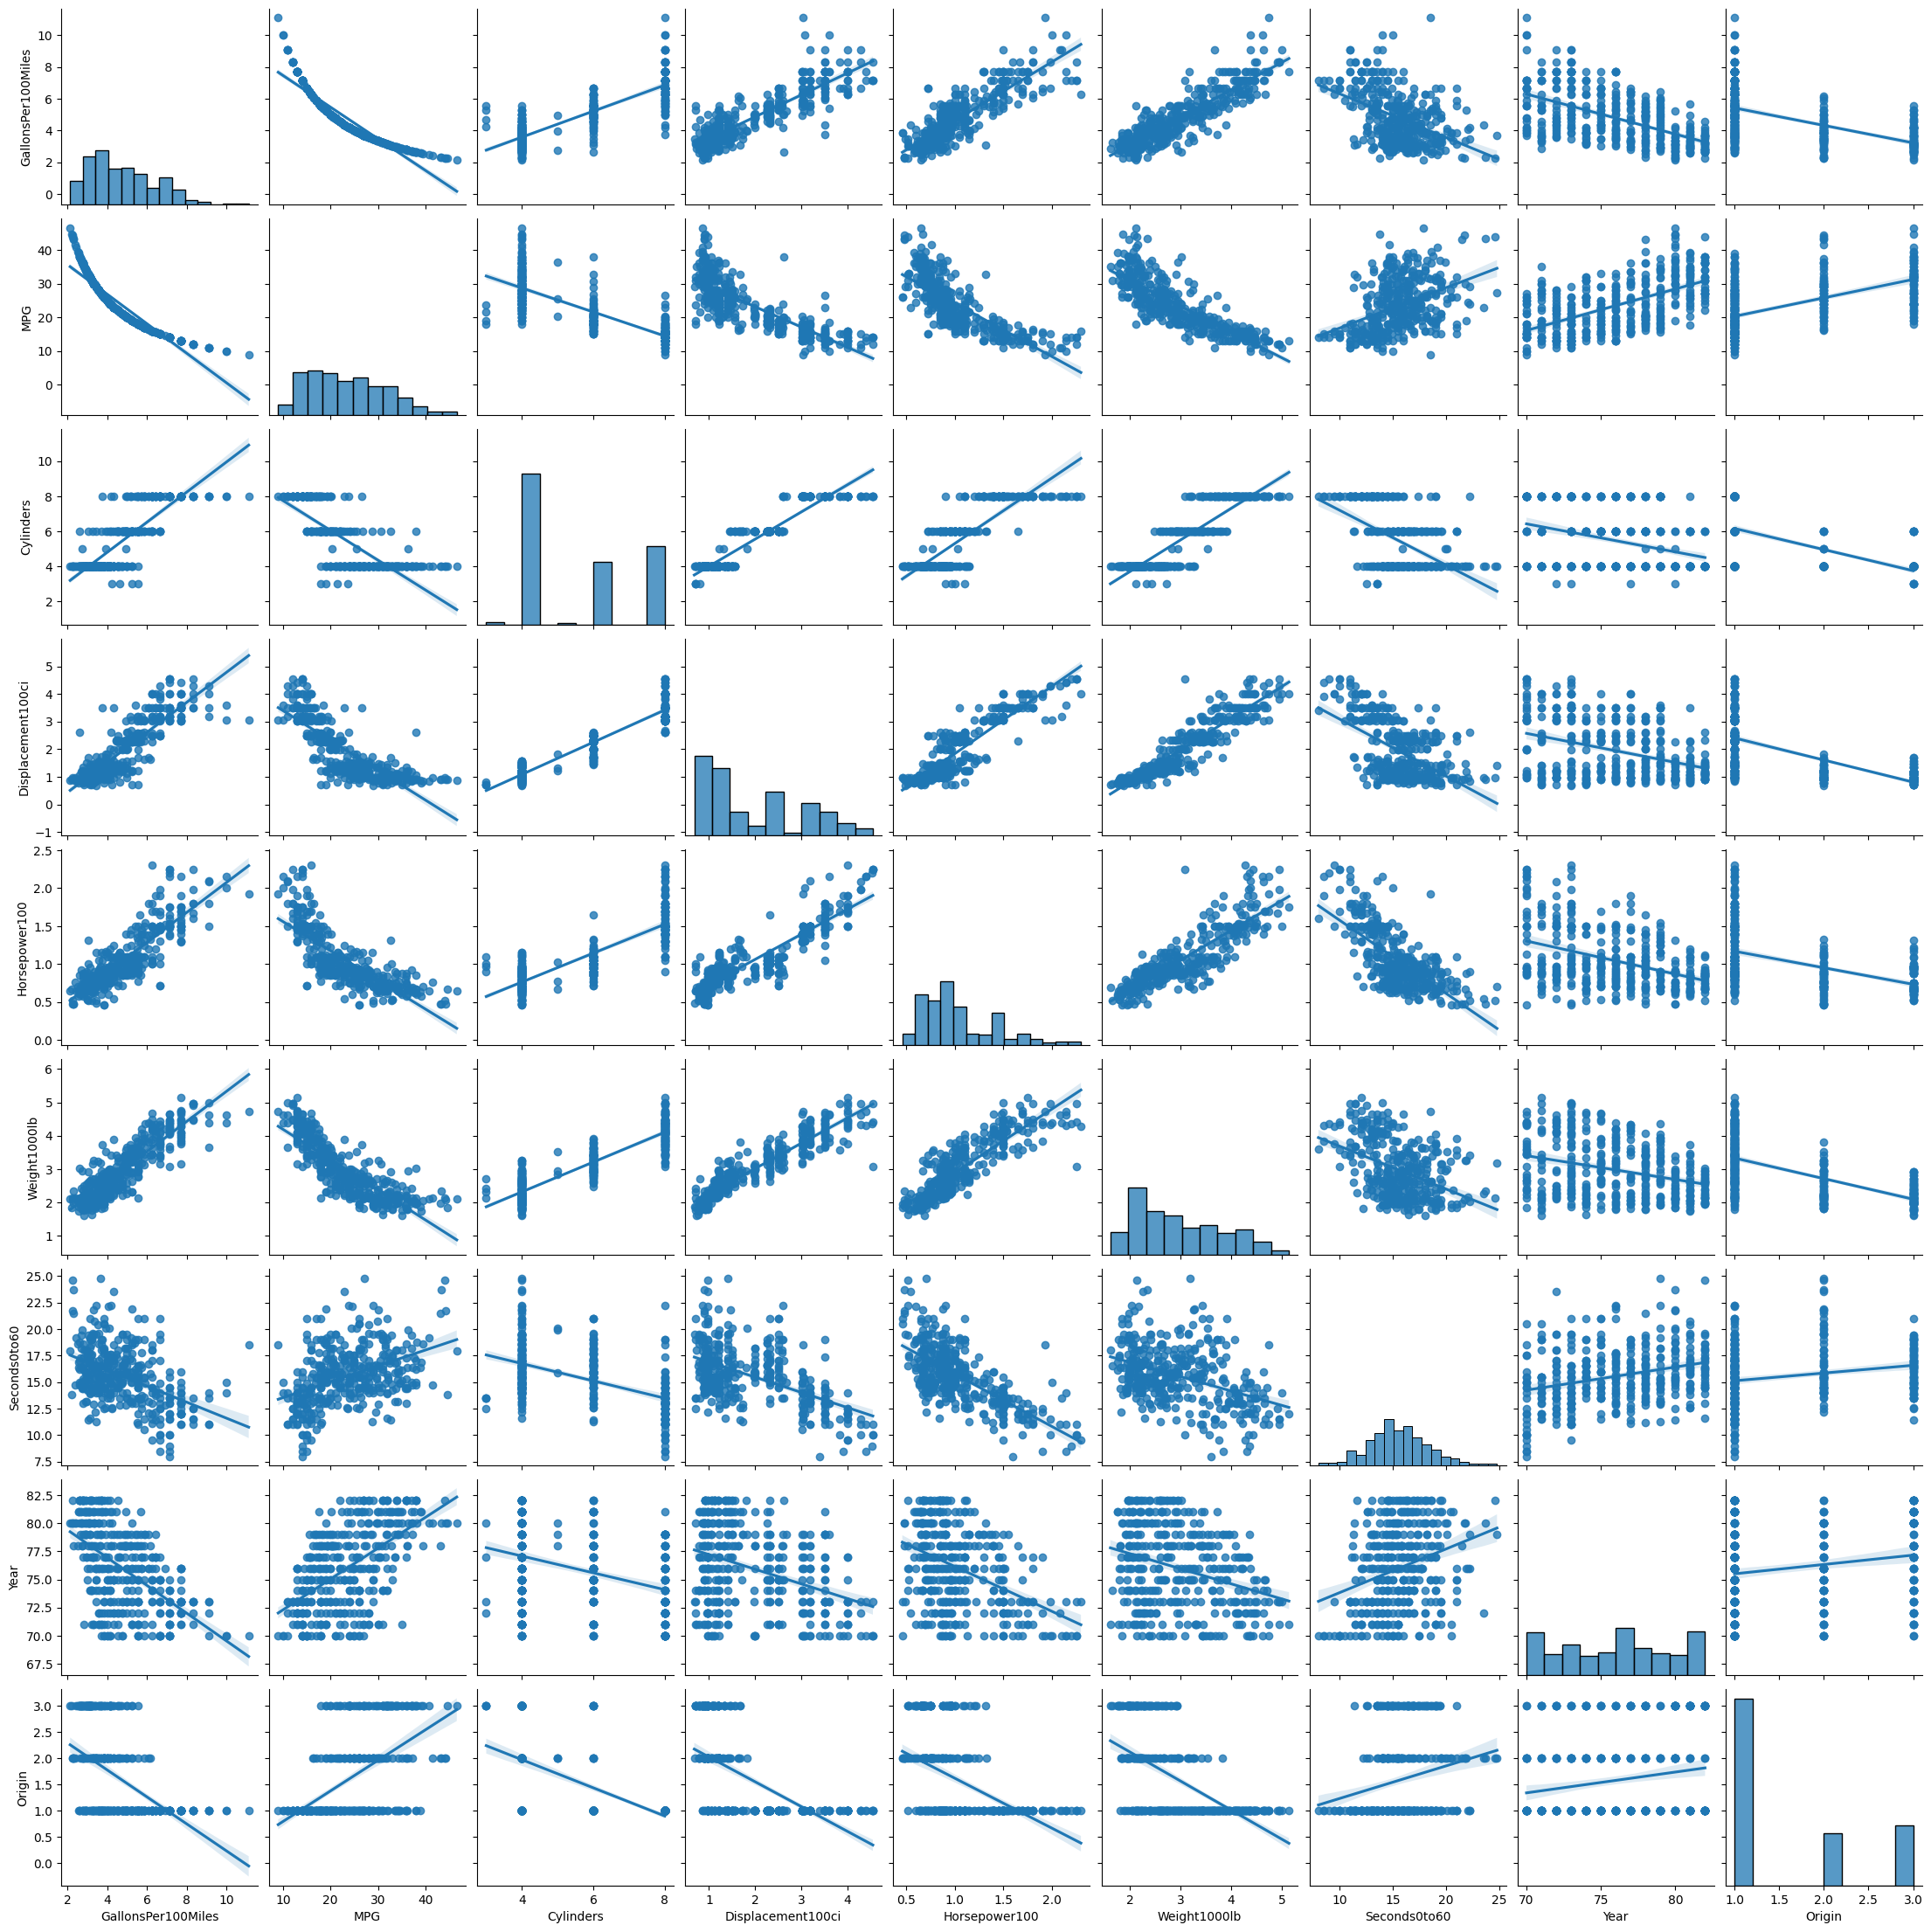

In [60]:
sns.pairplot(df, kind='reg')

## Correlation Analysis
Computing the correlation matrix.

In [46]:
df.corr()

,GallonsPer100Miles,GallonsPer100MilesTo1981,MPG,Cylinders,Displacement100ci,Horsepower100,Weight1000lb,Seconds0to60,Year,Origin
GallonsPer100Miles,1.000000,1.000000,-0.935935,0.839385,0.866050,0.854809,0.885056,-0.456338,-0.558255,-0.532932
GallonsPer100MilesTo1981,1.000000,1.000000,-0.934841,0.835720,0.866894,0.853023,0.884828,-0.461391,-0.508736,-0.560899
MPG,-0.935935,-0.934841,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
Cylinders,0.839385,0.835720,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
Displacement100ci,0.866050,0.866894,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
Horsepower100,0.854809,0.853023,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
Weight1000lb,0.885056,0.884828,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
Seconds0to60,-0.456338,-0.461391,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
Year,-0.558255,-0.508736,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
Origin,-0.532932,-0.560899,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


## Visualizing Correlations
We use a heatmap to visualize the correlations between numerical columns.

<Axes: >

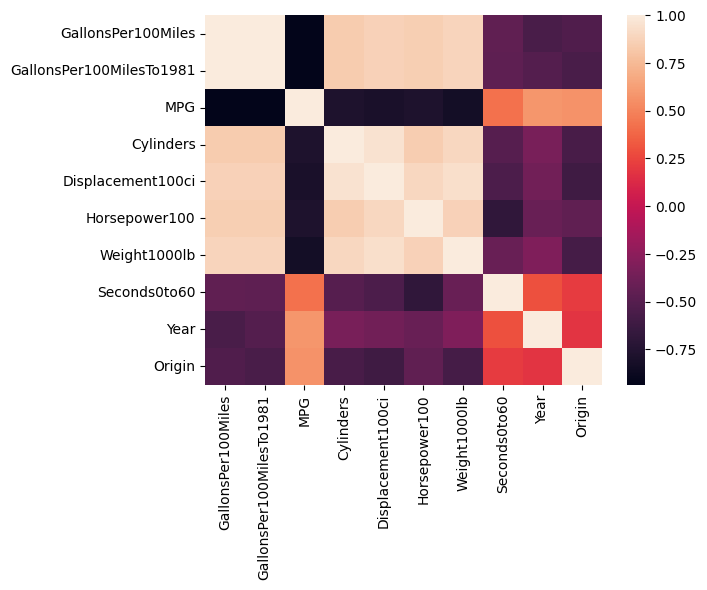

In [47]:
sns.heatmap(df.corr())

## Joint Distributions
Creating joint plots to explore relationships between key variables.

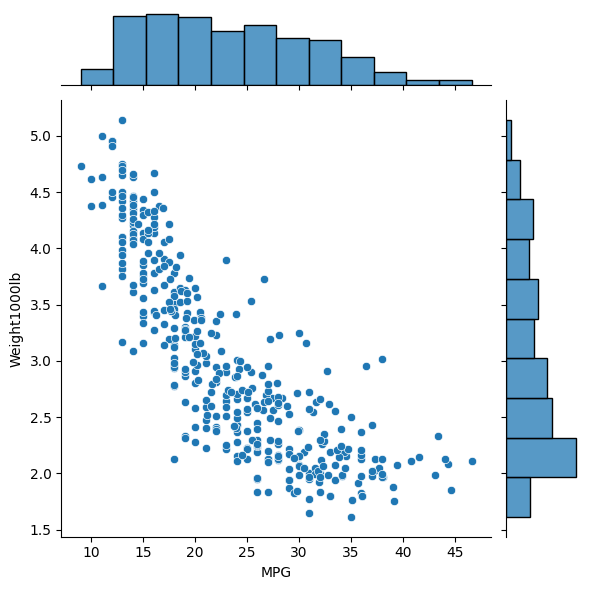

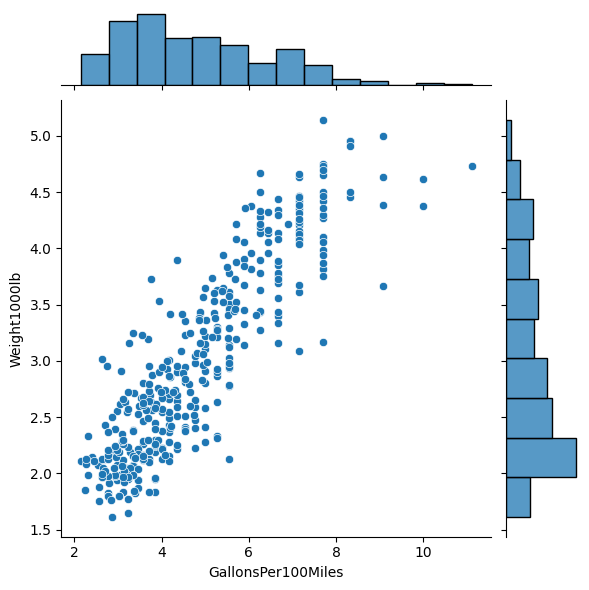

In [48]:
sns.jointplot(data=df, x='MPG', y='Weight1000lb')
sns.jointplot(data=df, x='GallonsPer100Miles', y='Weight1000lb')

#### MPG vs. Weight (in 1000 lbs):

- Scatter Plot: Shows an expected negative correlation—heavier vehicles tend to have lower MPG, indicating reduced fuel efficiency as weight increases.
- Marginal Histograms: Highlight the most common ranges of MPG and Weight1000lb.

##### Gallons Per 100 Miles vs. Weight (in 1000 lbs):

- Scatter Plot: Demonstrates a positive correlation—heavier vehicles consume more fuel per 100 miles.
- Marginal Histograms: Show the distribution of GallonsPer100Miles and Weight1000lb.

Both plots confirm intuitive relationships between vehicle weight and fuel efficiency/consumption.

## Linear Regression Model
Building and evaluating a simple linear regression model.

In [49]:
X = df['Weight1000lb'].to_frame() # Converts the Weight1000lb column into a DataFrame (required format for the regression model).
y = df['GallonsPer100Miles'] # the dependent variable (target), which is the fuel consumption in gallons per 100 miles.
fuel_model = LinearRegression().fit(X, y)
fuel_model.coef_, fuel_model.intercept_

(array([1.73378735]), -0.3802549901551391)

- For every additional 1000 lbs in vehicle weight, the fuel consumption (GallonsPer100Miles) increases by approximately 1.73 gallons per 100 miles.
- Practical Meaning: Heavier vehicles are less fuel-efficient and require more fuel for the same distance.
- The second value is the Intercept : This is the predicted value of GallonsPer100Miles when the weight of the vehicle (Weight1000lb) is 0.


## Making Predictions
Using the trained model to predict values for new data points.

In [50]:
# Predict the fuel consumption (GallonsPer100Miles) for vehicles weighing 3000 lbs (3 in Weight1000lb) and 1000 lbs (1 in Weight1000lb).
fuel_model.predict(pd.DataFrame([3]))
fuel_model.predict(pd.DataFrame([1]))

c:\Users\spasi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\spasi\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1.35353236])

## Residual Analysis
Visualizing residuals to evaluate the fit of the regression model.

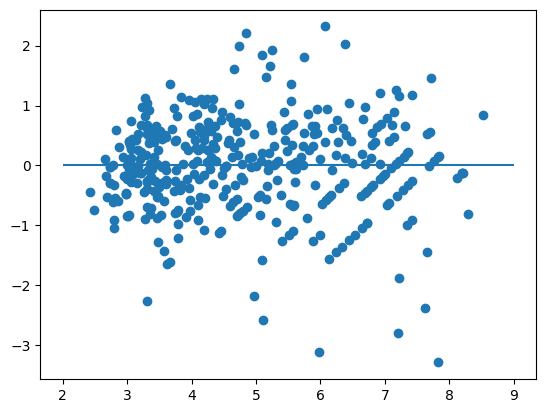

In [51]:
plt.scatter(fuel_model.predict(X), fuel_model.predict(X) - y)
plt.hlines(y=0, xmin=2, xmax=9)

- X-axis: Predicted values of GallonsPer100Miles (fuel_model.predict(X)).
- Y-axis: Residuals, calculated as the difference between predicted values and actual values (fuel_model.predict(X) - y).

- Residuals above this line indicate that the model over-predicted fuel consumption.
- Residuals below this line indicate that the model under-predicted fuel consumption.

- The residuals are distributed around the horizontal line at 𝑦=0, with no obvious pattern. This suggests the model reasonably fits the data.
- Most residuals are close to zero, indicating that the predictions are generally accurate.
- Larger residuals (points farther from the line) indicate instances where the model's predictions deviate more significantly from actual values.
- There is no clear curve or systematic trend in the residuals, supporting the assumption of linearity.
- Points significantly above or below the line might be outliers or instances where the model underperforms.

## Model Performance
Calculating the R-squared score to assess the performance of the model.

In [52]:
fuel_model.score(X, y)

0.7833240828863839

- The R-squared value indicates that approximately 78.33% of the variability in the target variable (GallonsPer100Miles) can be explained by the predictor variable (Weight1000lb).
- A score of 0.7833 suggests that the model provides a strong fit to the data but does not capture all the variability. There might be other factors influencing GallonsPer100Miles that are not included in the model.
- **Room for Improvement:** Adding more relevant features (e.g., Horsepower100, Cylinders) or using a more complex model might improve the R-squared value.


#### More Features
- creates three sets of independent variables (X1, X2, X3) for predicting the dependent variable y = df['GallonsPer100Miles']. Each set includes a different combination of features from the dataset.
- X1: Includes all key features related to engine specifications and vehicle dynamics for predicting GallonsPer100Miles. This comprehensive set might provide the most accurate predictions.
- X2: Focuses on engine power and vehicle weight, excluding Cylinders and Seconds0to60. It assumes these three features are the most directly relevant to fuel consumption.
- X3: Uses the number of cylinders, engine size, and acceleration time, omitting Horsepower100 and Weight1000lb. This set might emphasize the physical properties of the engine and vehicle performance over weight.


In [53]:
y = df['GallonsPer100Miles']
X1 = df[['Cylinders', 'Displacement100ci', 'Horsepower100', 'Weight1000lb', 'Seconds0to60']]
X2 = df[['Displacement100ci', 'Horsepower100', 'Weight1000lb']]
X3 = df[['Cylinders', 'Displacement100ci', 'Seconds0to60']]

In [54]:
fuel_model1 = LinearRegression().fit(X1,y)
fuel_model2 = LinearRegression().fit(X2,y)
fuel_model3 = LinearRegression().fit(X3,y)

In [55]:
print(fuel_model1.score(X1,y))
print(fuel_model2.score(X2,y))
print(fuel_model3.score(X3,y))

0.8207948199718269
0.8158213878482583
0.7529103569205208


- Model with X1: This model has the highest R-squared score, meaning it explains approximately 82.08% of the variability in GallonsPer100Miles. Including all five features provides the best fit to the data.